In [136]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.Descriptors import ExactMolWt
from rdkit.Chem.rdMolDescriptors import CalcMolFormula
from rdkit import RDLogger
IPythonConsole.molSize = (450, 450)
import pickle as pkl
import numpy as np
import pandas as pd
from sys import path
path.append('../src')
from src.metrics.diffms_metrics import K_ACC_Collection
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
import warnings
RDLogger.DisableLog('rdApp.*')

In [62]:
pred_arrs = []
true_arrs = []
for i in range(0, 16):
    with open(f'data/gecko_neims_preds/dev_pred_{i}.pkl', 'rb') as f:
        pred_arr = pkl.load(f)
    with open(f'data/gecko_neims_preds/dev_true_{i}.pkl', 'rb') as f:
        true_arr = pkl.load(f)
    pred_arrs.append(pred_arr)
    true_arrs.append(true_arr)
pred_mols = np.array(pred_arrs).reshape((16384, 10))
true_mols = np.array(true_arrs).flatten()
print(f'true_mols.shape: {true_mols.shape}')
print(f'pred_mols.shape: {pred_mols.shape}')

true_mols.shape: (16384,)
pred_mols.shape: (16384, 10)


In [63]:
matches_idx = []
no_matches_idx = []
for idx, true_mol in enumerate(true_mols):
    found_match = False
    true_inchi = Chem.MolToInchi(true_mol)
    for pred_mol in pred_mols[idx]:
        try:
            pred_inchi = Chem.MolToInchi(pred_mol)
            if pred_inchi == true_inchi:
                found_match = True
        except:
            print('Invalid molecule')
    if found_match:
        matches_idx.append(idx)
    else:
        no_matches_idx.append(idx)

Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule
Invalid molecule


In [64]:
matches_idx = np.array(matches_idx)
no_matches_idx = np.array(no_matches_idx)

In [65]:
matches_idx.shape

(3198,)

In [66]:
no_matches_idx.shape

(13186,)

In [87]:
idx_iter = iter(matches_idx)

971


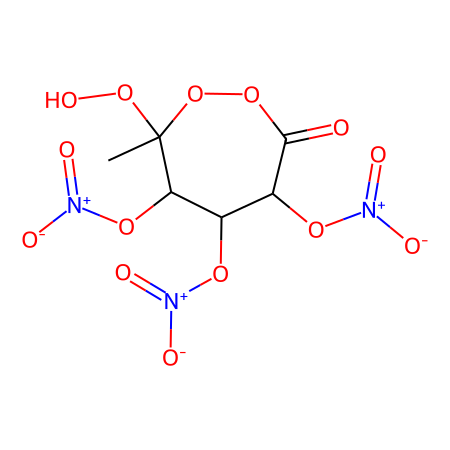

In [382]:
#mol_idx = next(idx_iter)
mol_idx = 971
true_mol = true_mols[mol_idx]
print(mol_idx)
true_mol

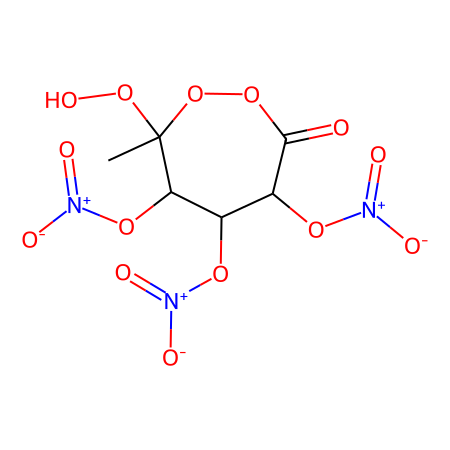

In [383]:
mol = true_mol
mol

In [384]:
drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)
opts = drawer.drawOptions()
opts.baseFontSize = 0.7   # default ~0.6, increase this
rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()
with open(f"figs/blog/{mol_idx}_true.svg", "w") as f:
    f.write(svg)
preds = iter(pred_mols[mol_idx])
pred_mol_idx = 0

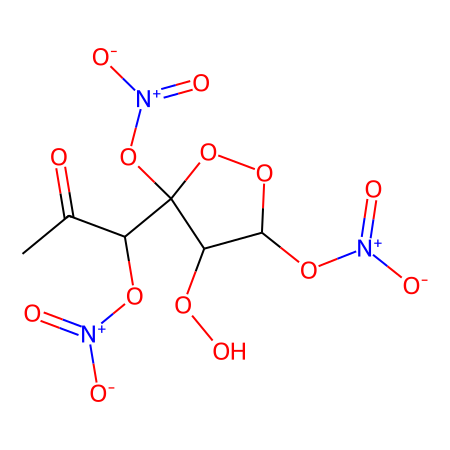

In [385]:
pred_mol = next(preds)
pred_mol


In [386]:
preds_to_draw = pred_mols[mol_idx]
for i, pred in enumerate(preds_to_draw):
    drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)

    opts = drawer.drawOptions()
    opts.baseFontSize = 0.7   # default ~0.6, increase this
    # optional tweaks:
    # opts.minFontSize = 16
    # opts.maxFontSize = 40

    rdMolDraw2D.PrepareAndDrawMolecule(drawer, pred)
    drawer.FinishDrawing()

    svg = drawer.GetDrawingText()
    with open(f"figs/blog/{mol_idx}_pred_{i}.svg", "w") as f:
        f.write(svg)

In [72]:
import matplotlib.pyplot as plt

def make_fig(df, name: str, annotate=True, min_intensity=0.1):
    spec = df[df['name'] == name]['spec'].values[0].T
    mz = spec[0, :]
    inten = spec[1, :]
    inten_scaled = inten / inten.max()

    #mask = inten_scaled > min_intensity
    #inten_scaled = inten_scaled[mask]
    #mz = mz[mask]

    plt.figure(figsize=(8, 3.8), dpi=350)
    plt.vlines(mz, 0, inten_scaled, color='#e1aee4', linewidth=1.5)

    # 🔹 Add labels on top of peaks
    if annotate:
        for x, y in zip(mz, inten_scaled):
            if y >= min_intensity:  # avoid clutter from tiny peaks
                plt.text(
                    x, y + 0.02,           # slight vertical offset
                    f"{int(round(x))}",    # label = m/z value
                    ha='center',
                    va='bottom',
                    fontsize=7
                )

    plt.xlabel('m/z')
    plt.ylabel('Relative intensity')
    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)
    plt.ylim([0, 1.05])
    plt.title('EI-MS spectrum (Model input)', fontsize=12)
    plt.tight_layout()
    plt.show()
def mol_from_smiles_df(df, name):
    return Chem.MolFromSmiles(df[df['name'] == name]['SMILES'].values[0])

In [73]:
df = pd.read_pickle('../data/atmomaccs/spec_files/df_neims_atmomaccs_3_9_22.pkl')
df[df['name'] == 'ferraz-caetano_716']

,SMILES,spec,name
716,C12(C(C(C(C(C1(F)F)(F)F)(F)F)(F)F)(C(C(C(C2(F)...,"[[31, 166], [43, 230], [44, 102], [47, 0], [50...",ferraz-caetano_716


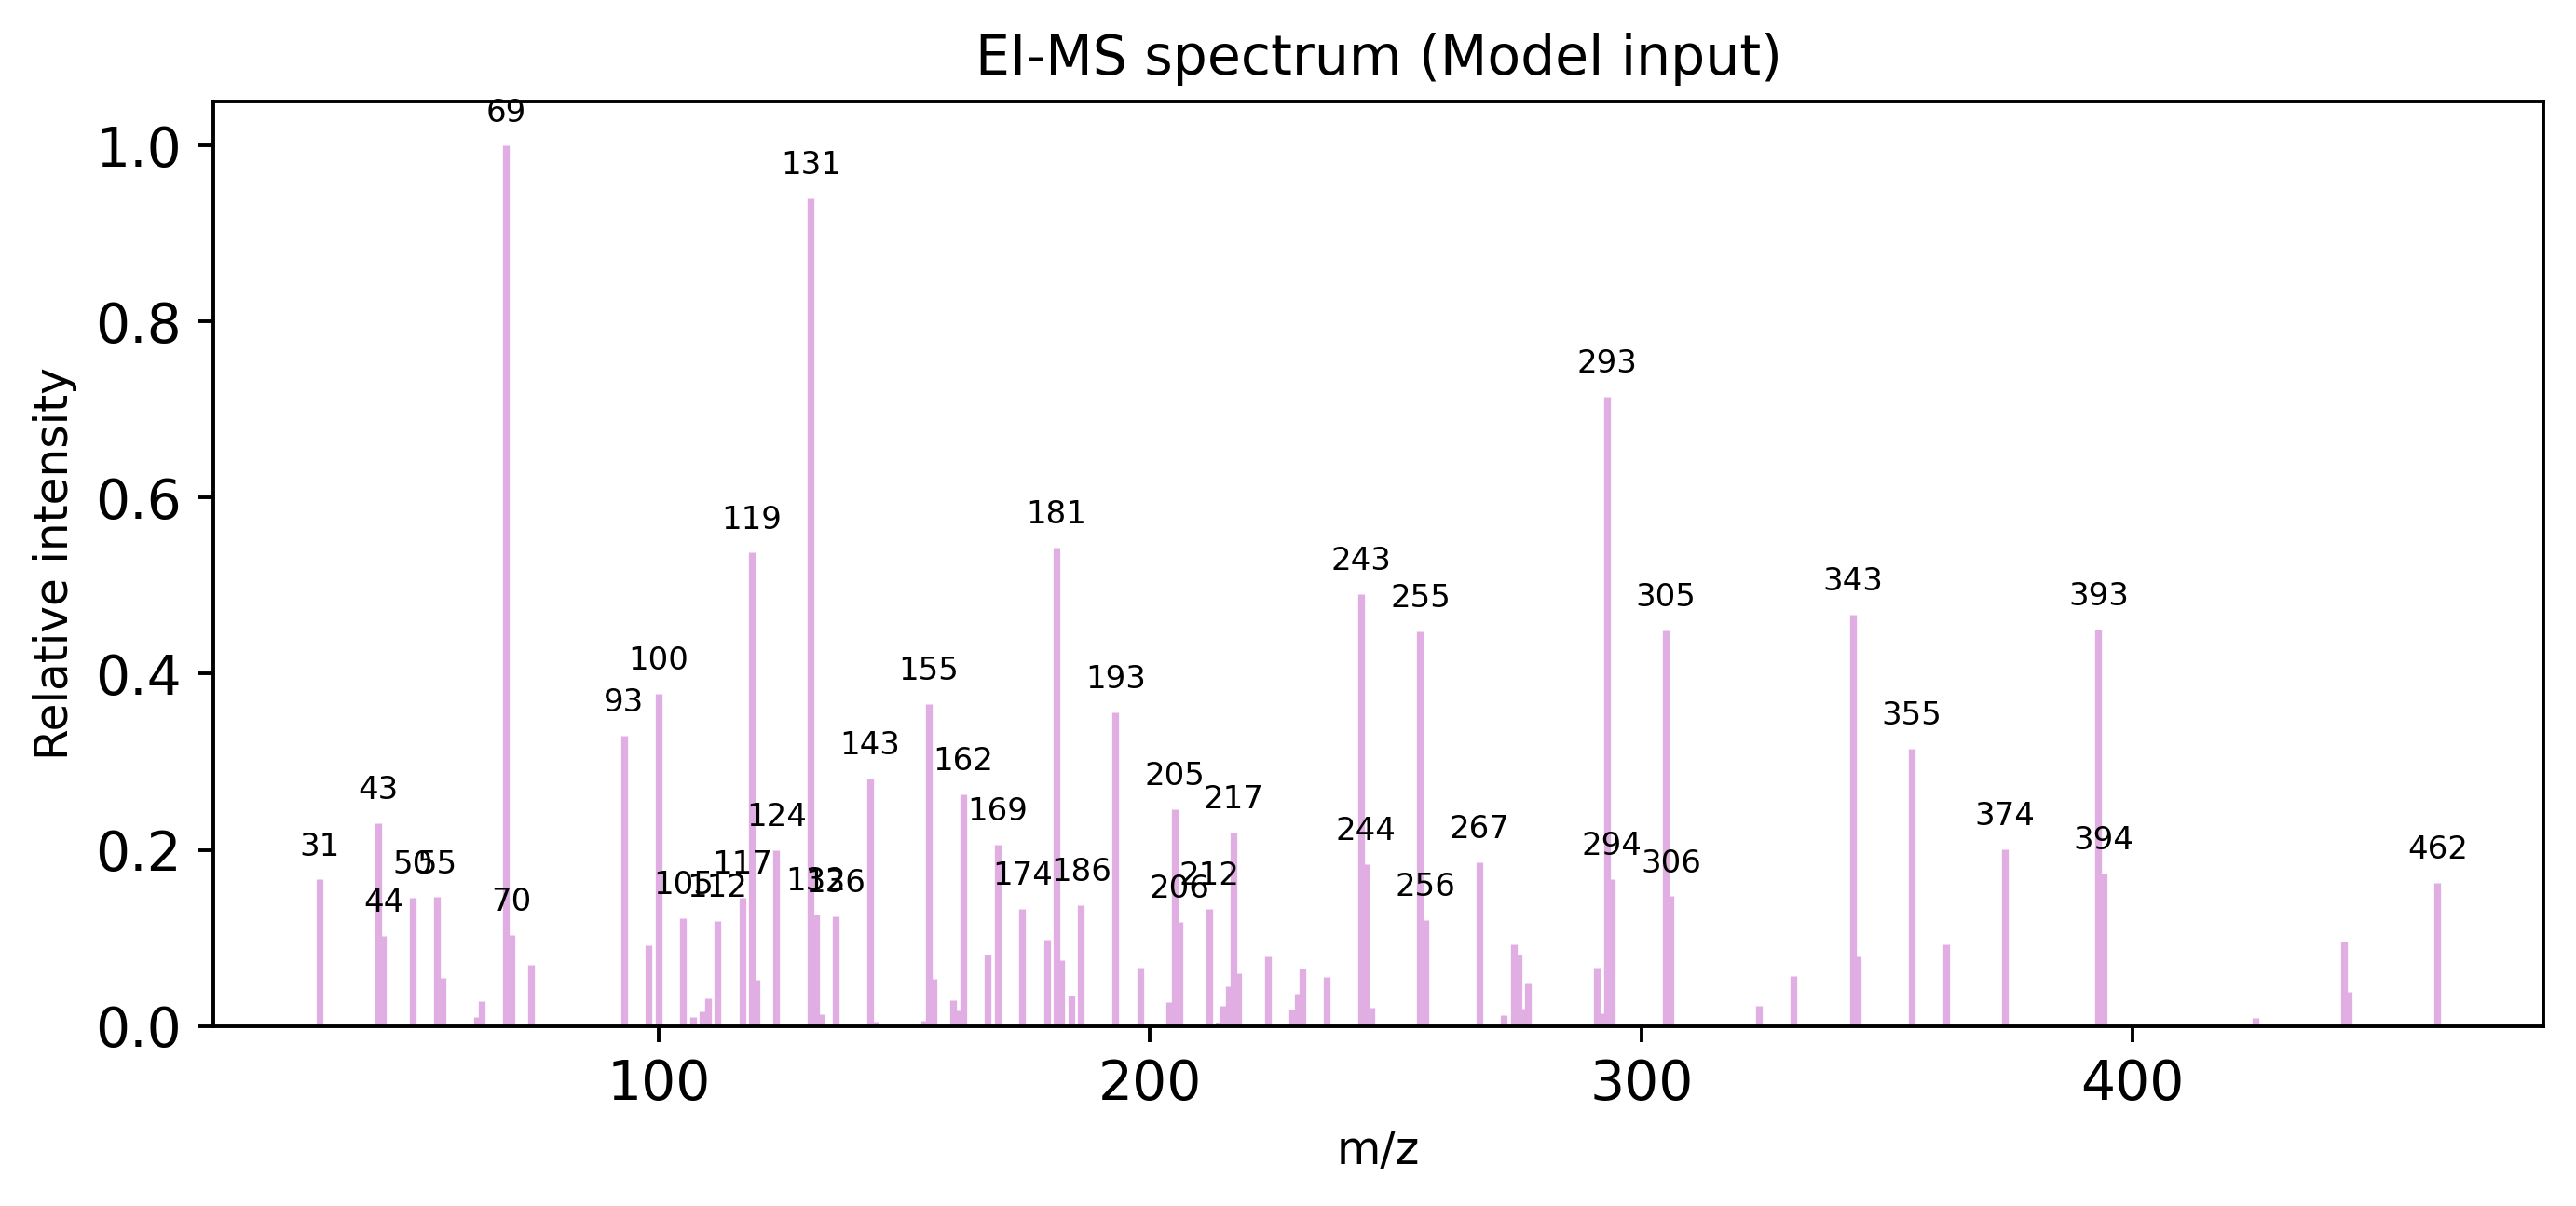

In [74]:
make_fig(df, 'ferraz-caetano_716')

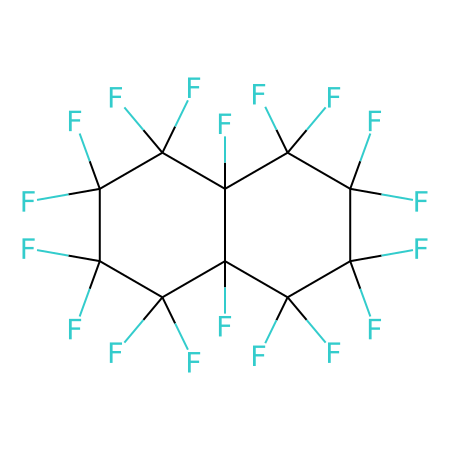

In [75]:
mol_from_smiles_df(df, 'ferraz-caetano_716')

In [76]:
raise Exception

Exception: 

In [ ]:
metric = K_ACC_Collection(k_list=[1, 5, 10])
metric.reset()

for pred_arr, true_arr in zip(pred_arrs, true_arrs):   # loop over the 5 files
    for preds, true_smiles in zip(pred_arr, true_arr): # loop inside each file
        metric.update(preds, true_smiles)

results = metric.compute()
results

{'acc_at_1': 0.0107421875,
 'acc_at_5': 0.034505208333333336,
 'acc_at_10': 0.04296875}

In [ ]:
pred_arrs = []
true_arrs = []
for i in range(0, 5):
    with open(f'data/outputs/dev_pred_{i}.pkl', 'rb') as f:
        pred_arr = pkl.load(f)
    with open(f'data/outputs/dev_true_{i}.pkl', 'rb') as f:
        true_arr = pkl.load(f)
    pred_arrs.append(pred_arr)
    true_arrs.append(true_arr)

In [ ]:
metric = K_ACC_Collection(k_list=[1, 5, 10])
metric.reset()

for pred_arr, true_arr in zip(pred_arrs, true_arrs):   # loop over the 5 files
    for preds, true_smiles in zip(pred_arr, true_arr): # loop inside each file
        metric.update(preds, true_smiles)

results = metric.compute()
results

{'acc_at_1': 0.6689453125, 'acc_at_5': 0.91875, 'acc_at_10': 0.9453125}